------

# Linear regression assumptions

The purpose of this notebook is to outline to assumptions of the linear regression model and demonstrate why they are important. Note that the form of the 

-----

## Errors are independent of the predictors (exogeneity)

If the residuals are correlated with the predictors, we could end up with biased predictor coefficients meaning that the estimated value of the coefficients is not necessarily equal to the true value, even when averaged over many samples. 

This can occur when there are two correlated predictors that each influence the response independently, but one of the predictors is omitted from the estimator. For example, both $LevelOfEducation$ and $Ability$ are predictors of $Salary$, and are also correlated with each other. If we only include one these predictors then we may assume a relationship of the form $Wage = \beta_{0} + \beta_{1}*LevelOfEducation + \epsilon$ where now the relationship between $Ability$ and $Salary$ is included in the error term. When we fit this model, we will attribute the effect of $Ability$ to $LevelOfEducation$ variable, which means that the estimated coefficient for this variable will not be equal to the true value even when averaged over many samples, i.e. it is biased: $\hat{\beta}_{1} != \beta_{1}$.

We will reproduce an example such as this below. We create two correlated variables that both influence the response, $Y = \beta_{0} + \beta_{1}*X_{1} + \beta_{2}*X_{2} + \epsilon$, and ensure that $X_{1}$ and $X_{2}$ are correlated. When regressing on both variables, we see that the estimate for $\beta_{1}$ is very close to the true value, but it changes significantly when excluding it. Note that this is often a significant problem for inference but the consequences may not be so siginificant for prediction. By reducing the true coefficient for X2 in the codeblock below, we can reduce the difference between the RMSE of the full model and the partial model, whilst still having a significant impact on the estimated coefficient for X1. Depending on the use case for the linear regression model, a lack of exogeneity may not be such a big issue.

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import root_mean_squared_error

np.random.seed(666)

# Sample size
n = 100

# True model: Y depends on X1 and X2, where X2 is correlated with X1
X1 = np.random.normal(0, 1, n)
X2 = 0.7 * X1 + np.random.normal(0, 0.5, n)

# True coefficients
beta0, beta1, beta2 = 2, 3, 5

# Response variable with noise
eps = np.random.normal(0, 1, n)
Y = beta0 + beta1 * X1 + beta2 * X2 + eps

# --- Model 1: Uses both X1 and X2
X_full = sm.add_constant(np.column_stack([X1, X2]))
model_full = sm.OLS(Y, X_full).fit()
preds_full = model_full.predict(X_full)
rmse_full = root_mean_squared_error(Y, preds_full)

# --- Model 2: regress only with X1
X_partial = sm.add_constant(X1)
model_partial = sm.OLS(Y, X_partial).fit()
preds_partial = model_partial.predict(X_partial)
rmse_partial = root_mean_squared_error(Y, preds_partial)

df_results = pd.DataFrame(
    {
        "X1_coef": [beta1, model_full.params[1], model_partial.params[1]],
        "p-value": [np.NaN, model_full.pvalues[1], model_partial.pvalues[1]],
        "RMSE": [np.NaN, rmse_full, rmse_partial]
    }, index=["TrueValue", "FullModel", "PartialModel"]
)

df_results


,X1_coef,p-value,RMSE
TrueValue,3.000000,NaN,NaN
FullModel,3.119946,4.487980e-31,1.014542
PartialModel,6.808402,1.007570e-41,2.774252


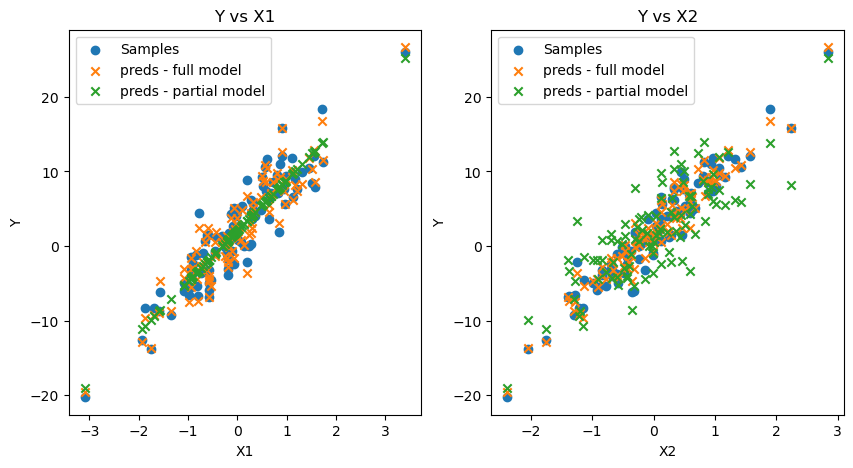

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

ax1.scatter(X1, Y, label="Samples")
ax1.scatter(X1, preds_full, marker="x", label="preds - full model")
ax1.scatter(X1, preds_partial, marker="x", label="preds - partial model")

ax2.scatter(X2, Y, label="Samples")
ax2.scatter(X2, preds_full, marker="x", label="preds - full model")
ax2.scatter(X2, preds_partial, marker="x", label="preds - partial model")

for ax, x in zip((ax1, ax2), ("X1", "X2")):
    ax.set_xlabel(x)
    ax.set_ylabel("Y")
    ax.set_title(f"Y vs {x}")
    ax.legend()